<a href="https://colab.research.google.com/github/mrunal-nikalje/Lung-Cancer-Prognosis-Using-Machine-Learning/blob/main/lung_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lung-Cancer-Prognosis-Using-Machine-Learning**



Comparative analysis of ML classifiers for lung cancer detection with optimized Logistic Regression (MLR) using threshold tuning (0.8 & 0.4) to improve accuracy.





In [ ]:
import pandas as pd
import matplotlib. pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
# Dataset URL (GitHub raw file link)
dataset_url = "https://raw.githubusercontent.com/rohitinu6/Lung_Cancer_Prediction_Using_Machine_Learning/main/Dataset/survey%20lung%20cancer.csv"


In [ ]:
import pandas as pd

# Dataset URL (GitHub raw file link)
dataset_url = "https://raw.githubusercontent.com/rohitinu6/Lung_Cancer_Prediction_Using_Machine_Learning/main/Dataset/survey%20lung%20cancer.csv"
# Read the CSV file directly from the URL
df = pd.read_csv(dataset_url)


lung_data = df.copy()

In [ ]:
lung_data

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [ ]:
lung_data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
lung_data.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES
308,M,62,1,1,1,2,1,2,2,2,2,1,1,2,1,YES


In [ ]:
#dependent_variable
x = lung_data.iloc[:,0:-1]
print(x)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                  1        2        1         2                  2         2   
1                  2 

In [ ]:
#independent_variable
y = lung_data. iloc[:,-1:]
print(y)

    LUNG_CANCER
0           YES
1           YES
2            NO
3            NO
4            NO
..          ...
304         YES
305         YES
306         YES
307         YES
308         YES

[309 rows x 1 columns]


In [ ]:
lung_data.GENDER = lung_data.GENDER.map({"M":1,"F":2})
lung_data.LUNG_CANCER = lung_data.LUNG_CANCER.map({"YES":1,"NO":2})

In [ ]:
lung_data.shape

(309, 16)

In [ ]:
lung_data.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [ ]:
lung_data.dtypes

,0
GENDER,int64
AGE,int64
SMOKING,int64
YELLOW_FINGERS,int64
ANXIETY,int64
PEER_PRESSURE,int64
CHRONIC DISEASE,int64
FATIGUE,int64
ALLERGY,int64
WHEEZING,int64


In [ ]:
lung_data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,2,59,1,1,1,2,1,2,1,2,1,2,2,1,2,2
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,2
4,2,63,1,2,1,1,1,1,1,2,1,2,2,1,1,2


In [ ]:
lung_data.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
304,2,56,1,1,1,2,2,2,1,1,2,2,2,2,1,1
305,1,70,2,1,1,1,1,2,2,2,2,2,2,1,2,1
306,1,58,2,1,1,1,1,1,2,2,2,2,1,1,2,1
307,1,67,2,1,2,1,1,2,2,1,2,2,2,1,2,1
308,1,62,1,1,1,2,1,2,2,2,2,1,1,2,1,1


In [ ]:
#the describe() method returns description of data in DataFrame
lung_data.describe()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,1.475728,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634,1.126214
std,0.500221,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588,0.332629
min,1.000000,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000
75%,2.000000,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
max,2.000000,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [ ]:
#the info() method prints information of the database
lung_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    int64
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    i

In [ ]:
#Splitting the Dataset: Training and Testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=1/3,random_state=0)

In [ ]:
lung_data['LUNG_CANCER'].value_counts()

,count
LUNG_CANCER,
1,270
2,39


In [ ]:
len(lung_data)

309

In [ ]:
len(x_test)

103

In [ ]:
len(x_train)

206

In [ ]:
#dependent_variable
x = lung_data.iloc[:,0:-1]
x

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2
2,2,59,1,1,1,2,1,2,1,2,1,2,2,1,2
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2
4,2,63,1,2,1,1,1,1,1,2,1,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,2,56,1,1,1,2,2,2,1,1,2,2,2,2,1
305,1,70,2,1,1,1,1,2,2,2,2,2,2,1,2
306,1,58,2,1,1,1,1,1,2,2,2,2,1,1,2
307,1,67,2,1,2,1,1,2,2,1,2,2,2,1,2


In [ ]:
#independent_variable
y = lung_data.iloc[:,-1:]
y

,LUNG_CANCER
0,1
1,1
2,2
3,2
4,2
...,...
304,1
305,1
306,1
307,1


In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=1/3,random_state=0)


KNN

In [ ]:
 from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#Fitting K-NN to the Training set
classifier = KNeighborsClassifier(n_neighbors = 3, metric = "minkowski", p = 2)
classifier.fit(x_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=3)

In [ ]:
#Predicting the Test set result
prediction2 = classifier.predict(x_test)

In [ ]:
prediction2

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
confusion_matrix(y_test,prediction2)

array([[85,  2],
       [14,  2]])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction2)
precision = precision_score(y_test, prediction2)
recall = recall_score(y_test, prediction2)
f1 = f1_score(y_test, prediction2)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8446601941747572
Precision: 0.8585858585858586
Recall: 0.9770114942528736
F1 score: 0.9139784946236559


In [ ]:
accuracy_score(y_test,prediction2)

0.8446601941747572

In [ ]:
# Assuming x_train and y_train are your training data
Model1 = LogisticRegression()  # Initialize the model
Model1.fit(x_train, y_train)   # Train the model

probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction2, average = None)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0.85858586, 0.5       ])

In [ ]:
recall_score(y_test, prediction2, average = None)

array([0.97701149, 0.125     ])

In [ ]:
f1_score(y_test, prediction2, average = None)

array([0.91397849, 0.2       ])

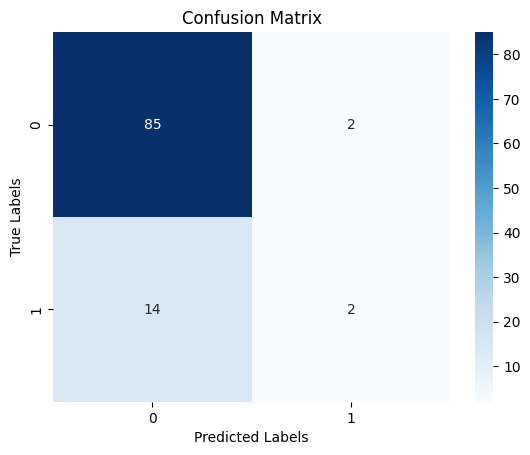

In [ ]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction2)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

Decision Tree


In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state = 0,criterion = "entropy")
tree.fit(x_train, y_train)
prediction3 = classifier.predict(x_test)

In [ ]:
prediction3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
confusion_matrix(y_test,prediction3)

array([[85,  2],
       [14,  2]])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction3)
precision = precision_score(y_test, prediction3)
recall = recall_score(y_test, prediction3)
f1 = f1_score(y_test, prediction3)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8446601941747572
Precision: 0.8585858585858586
Recall: 0.9770114942528736
F1 score: 0.9139784946236559


In [ ]:
accuracy_score(y_test,prediction3)

0.8446601941747572

In [ ]:
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction3, average = None)

array([0.85858586, 0.5       ])

In [ ]:
recall_score(y_test, prediction3, average = None)

array([0.97701149, 0.125     ])

In [ ]:
f1_score(y_test, prediction3, average = None)

array([0.91397849, 0.2       ])

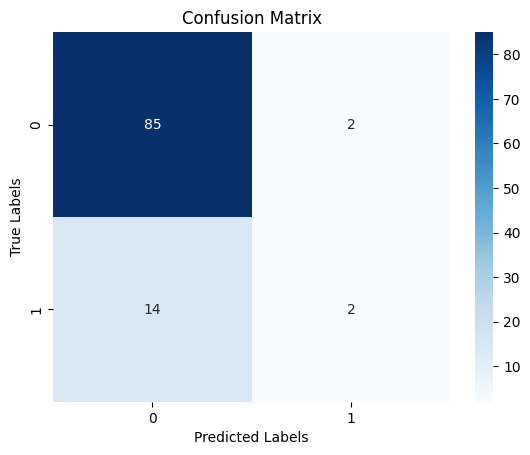

In [ ]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction3)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

SVM

In [ ]:
#Support Vector Machine
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
svm = OneVsRestClassifier(BaggingClassifier(SVC(C=10,kernel='rbf',random_state=9,probability=True),n_jobs=-1))
svm.fit(x_train, y_train)
prediction4 = svm.predict(x_test)

In [ ]:
confusion_matrix(y_test,prediction4)

array([[87,  0],
       [16,  0]])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction4)
precision = precision_score(y_test, prediction4)
recall = recall_score(y_test, prediction4)
f1 = f1_score(y_test, prediction4)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8446601941747572
Precision: 0.8446601941747572
Recall: 1.0
F1 score: 0.9157894736842105


In [ ]:
accuracy_score(y_test,prediction4)

0.8446601941747572

In [ ]:
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction4, average = None)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([0.84466019, 0.        ])

In [ ]:
recall_score(y_test, prediction4, average = None)

array([1., 0.])

In [ ]:
f1_score(y_test, prediction4, average = None)

array([0.91578947, 0.        ])

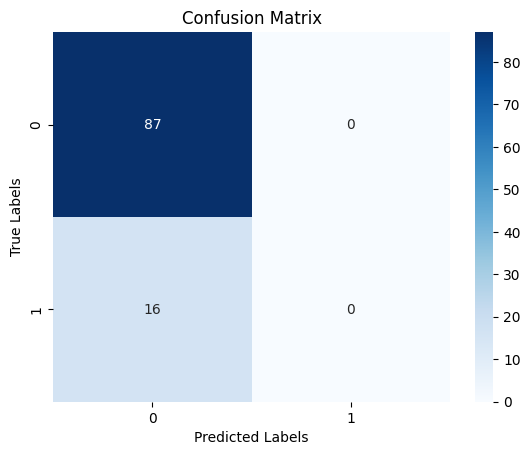

In [ ]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction4)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
nbcla = GaussianNB()
nbcla.fit(x_train, y_train)
prediction5 = nbcla.predict(x_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
confusion_matrix(y_test,prediction5)

array([[81,  6],
       [ 8,  8]])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction5)
precision = precision_score(y_test, prediction5)
recall = recall_score(y_test, prediction5)
f1 = f1_score(y_test, prediction5)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.8640776699029126
Precision: 0.9101123595505618
Recall: 0.9310344827586207
F1 score: 0.9204545454545454


In [ ]:
accuracy_score(y_test,prediction5)

0.8640776699029126

In [ ]:
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction5, average = None)

array([0.91011236, 0.57142857])

In [ ]:
recall_score(y_test, prediction5, average = None)

array([0.93103448, 0.5       ])

In [ ]:
f1_score(y_test, prediction5, average = None)

array([0.92045455, 0.53333333])

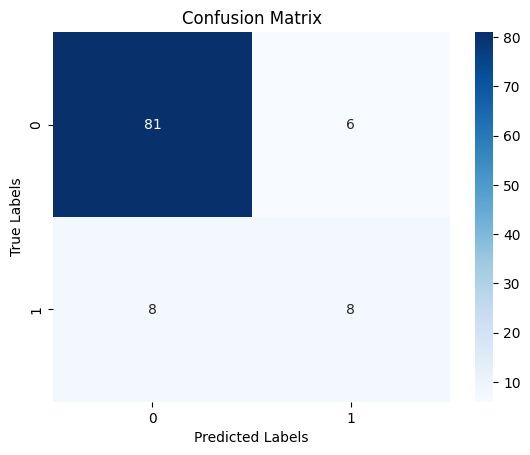

In [ ]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction5)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Finding Correlation
cn=lung_data.corr()
cn

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
GENDER,1.000000,-0.021306,-0.036277,0.212959,0.152127,0.275564,0.204606,0.083560,-0.154251,-0.141207,-0.454268,-0.133303,0.064911,0.078161,-0.362958,0.067254
AGE,-0.021306,1.000000,-0.084475,0.005205,0.053170,0.018685,-0.012642,0.012614,0.027990,0.055011,0.058985,0.169950,-0.017513,-0.001270,-0.018104,-0.089465
SMOKING,-0.036277,-0.084475,1.000000,-0.014585,0.160267,-0.042822,-0.141522,-0.029575,0.001913,-0.129426,-0.050623,-0.129471,0.061264,0.030718,0.120117,-0.058179
YELLOW_FINGERS,0.212959,0.005205,-0.014585,1.000000,0.565829,0.323083,0.041122,-0.118058,-0.144300,-0.078515,-0.289025,-0.012640,-0.105944,0.345904,-0.104829,-0.181339
ANXIETY,0.152127,0.053170,0.160267,0.565829,1.000000,0.216841,-0.009678,-0.188538,-0.165750,-0.191807,-0.165750,-0.225644,-0.144077,0.489403,-0.113634,-0.144947
PEER_PRESSURE,0.275564,0.018685,-0.042822,0.323083,0.216841,1.000000,0.048515,0.078148,-0.081800,-0.068771,-0.159973,-0.089019,-0.220175,0.366590,-0.094828,-0.186388
CHRONIC DISEASE,0.204606,-0.012642,-0.141522,0.041122,-0.009678,0.048515,1.000000,-0.110529,0.106386,-0.049967,0.002150,-0.175287,-0.026459,0.075176,-0.036938,-0.110891
FATIGUE,0.083560,0.012614,-0.029575,-0.118058,-0.188538,0.078148,-0.110529,1.000000,0.003056,0.141937,-0.191377,0.146856,0.441745,-0.132790,-0.010832,-0.150673
ALLERGY,-0.154251,0.027990,0.001913,-0.144300,-0.165750,-0.081800,0.106386,0.003056,1.000000,0.173867,0.344339,0.189524,-0.030056,-0.061508,0.239433,-0.327766
WHEEZING,-0.141207,0.055011,-0.129426,-0.078515,-0.191807,-0.068771,-0.049967,0.141937,0.173867,1.000000,0.265659,0.374265,0.037834,0.069027,0.147640,-0.249300


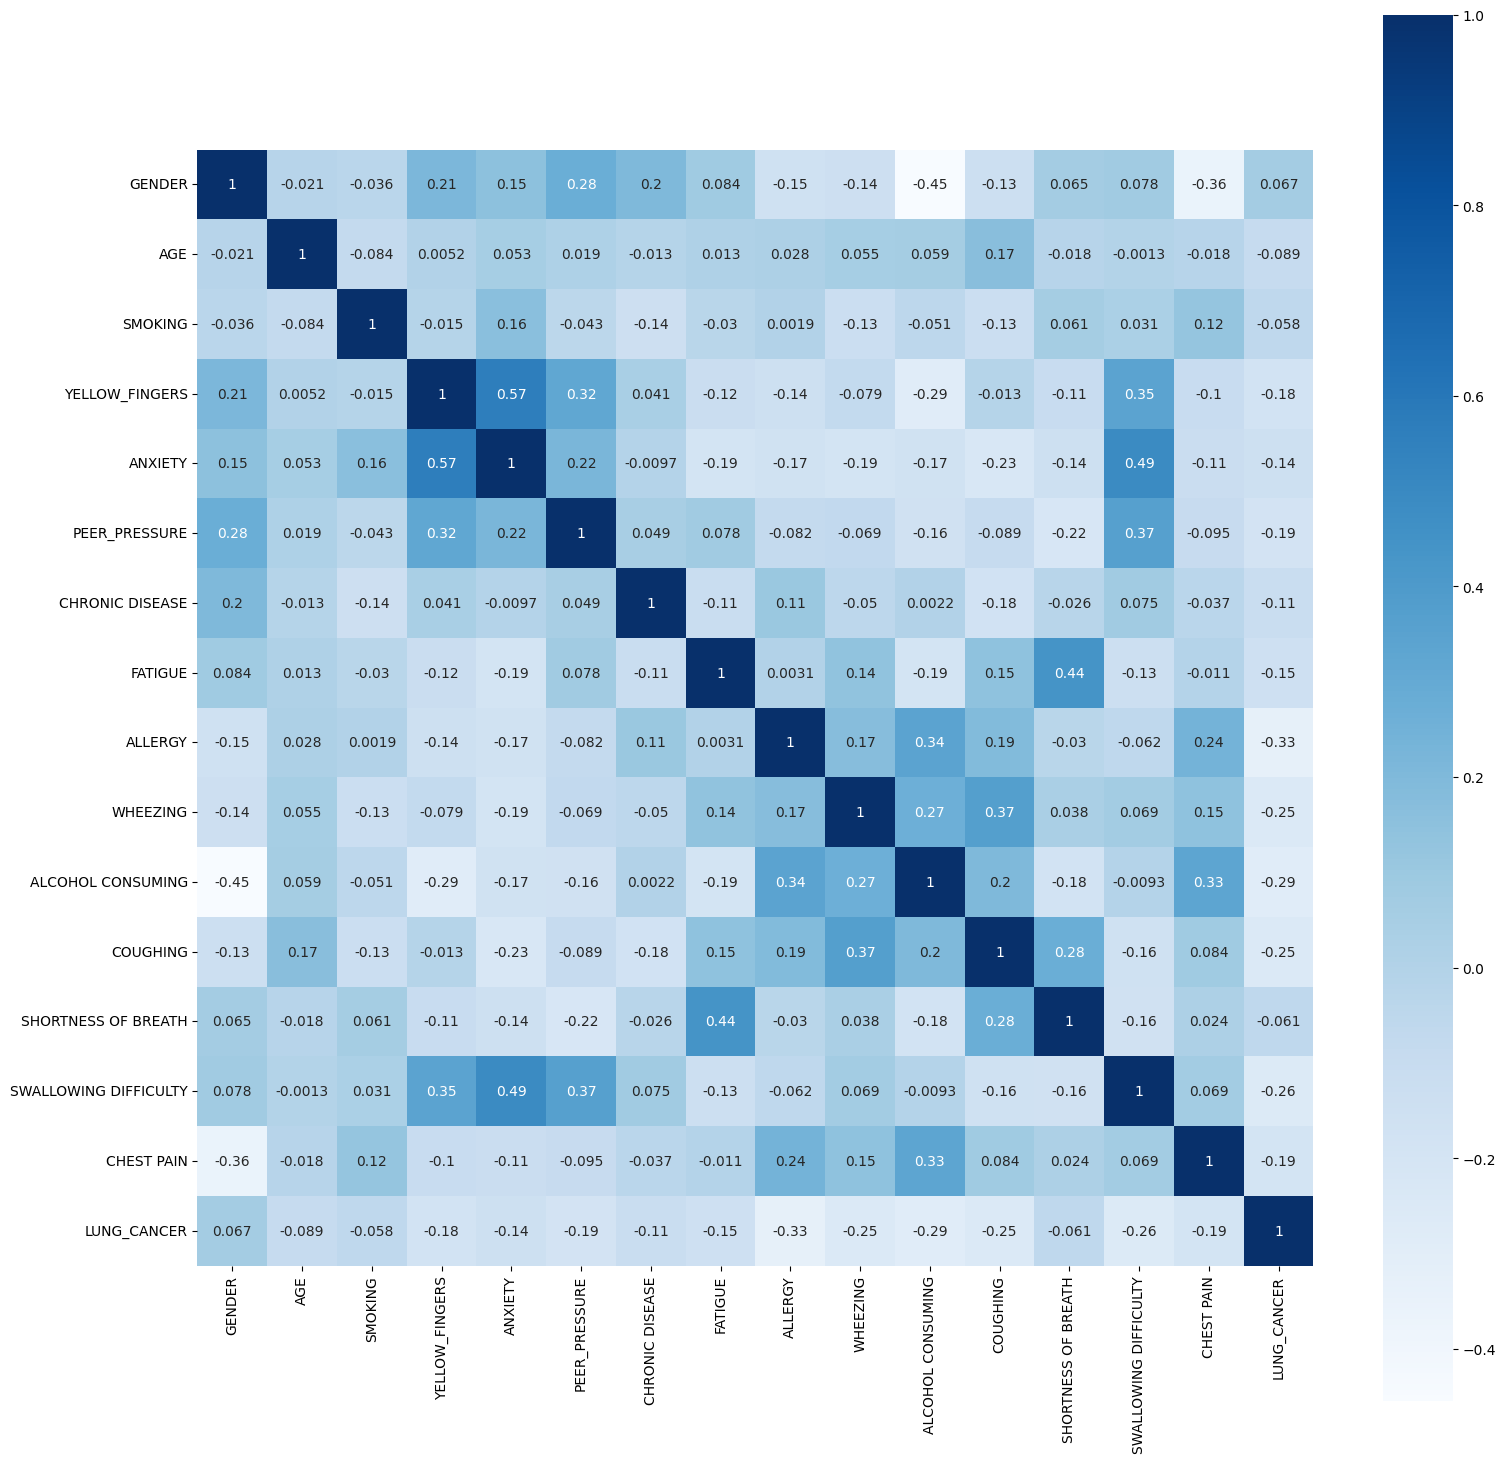

In [ ]:
#Correlation
cmap=sns.diverging_palette(260,-10,s=50, l=75, n=6,
as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn,cmap="Blues",annot=True, square=True)
plt.show()

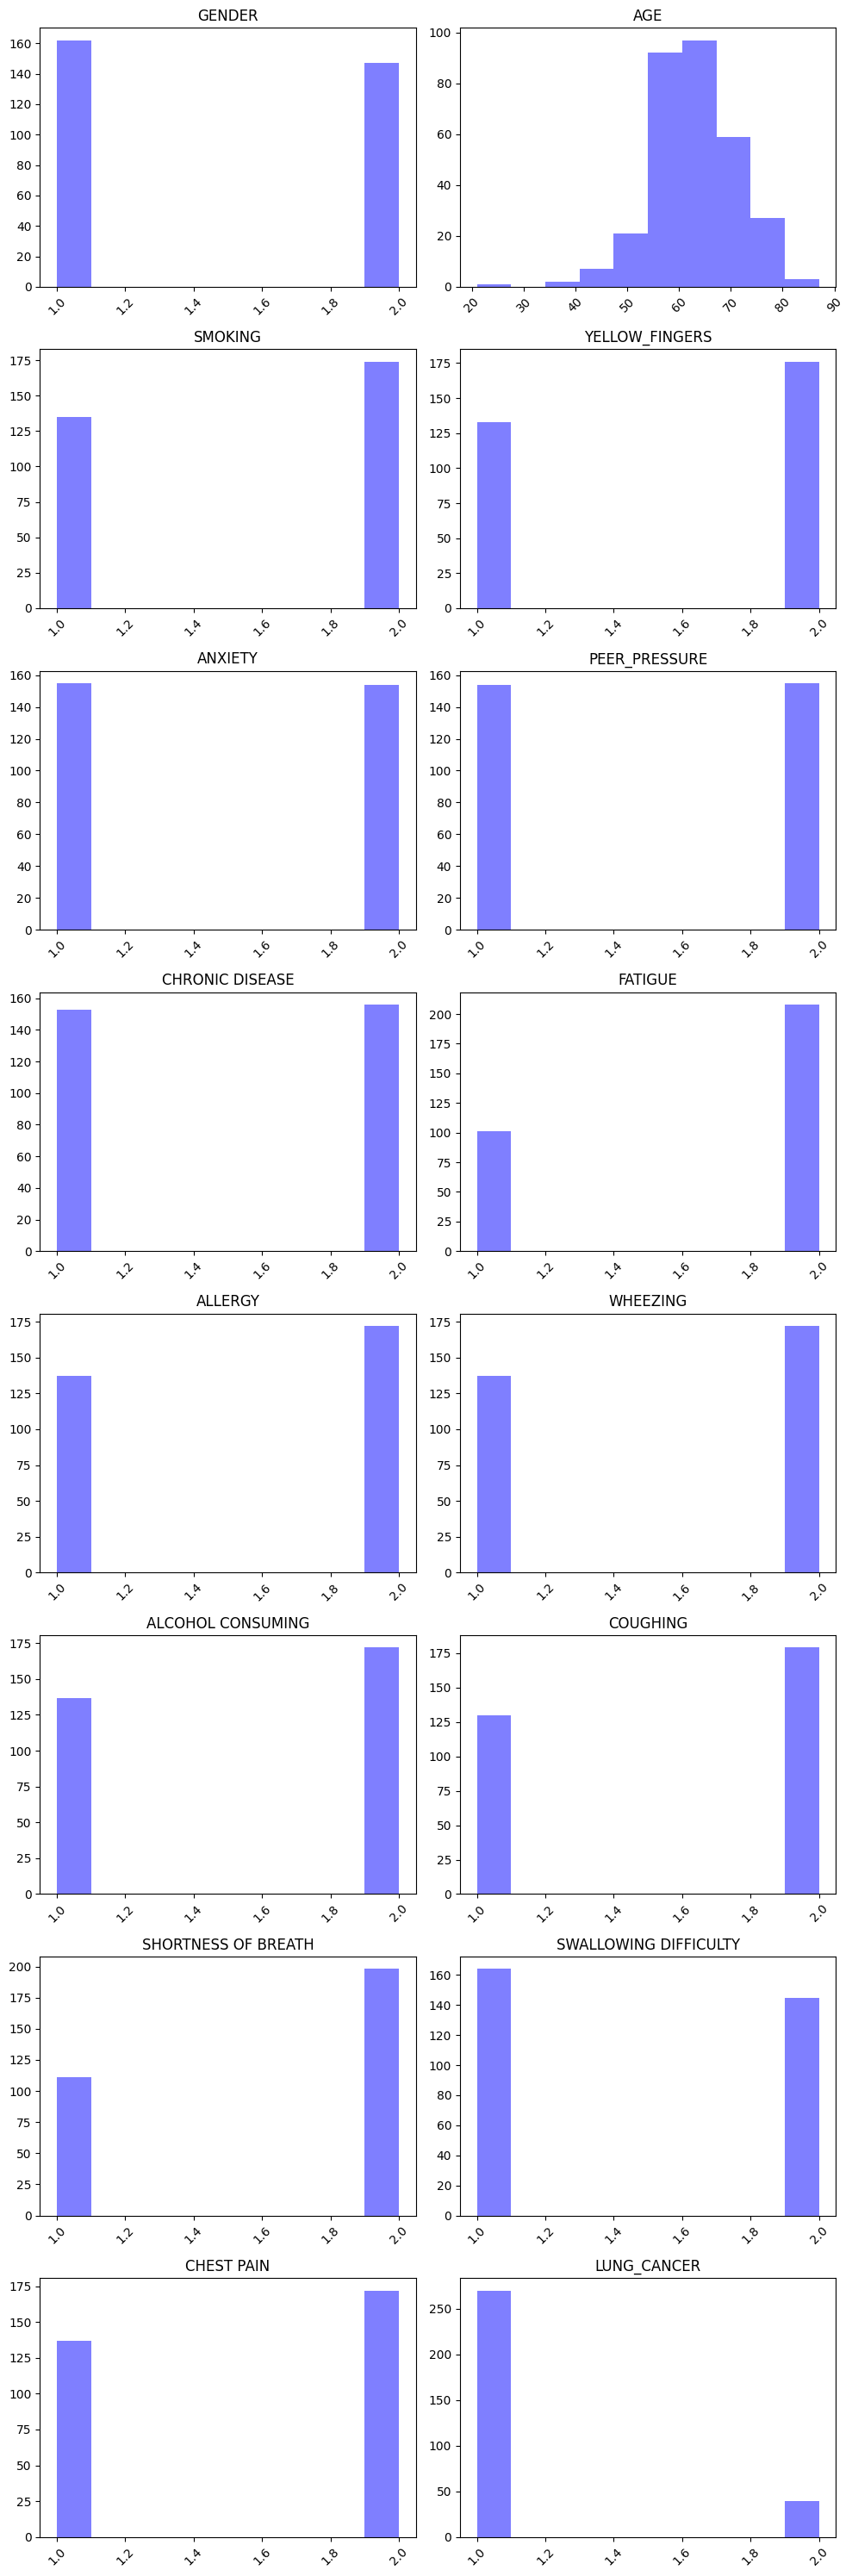

In [ ]:
num_list = list(lung_data.columns)

fig = plt.figure(figsize=(10,30))

for i in range(len(num_list)):
    plt.subplot(8,2,i+1)
    plt.title(num_list[i])
    plt.xticks(rotation=45)
    plt.hist(lung_data[num_list[i]],color='blue',alpha=0.5)

plt.tight_layout()

Neural Network

In [ ]:
!pip install scikit-learn
from sklearn.neural_network import MLPClassifier # Import MLPClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



mlp_classifier = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp_classifier.fit(x_train, y_train)
prediction_mlp = mlp_classifier.predict(x_test)
accuracy_mlp = accuracy_score(y_test, prediction_mlp)
precision_mlp = precision_score(y_test, prediction_mlp)
recall_mlp = recall_score(y_test, prediction_mlp)
f1_mlp = f1_score(y_test, prediction_mlp)
print("Neural Network - Accuracy:", accuracy_mlp)
print("Precision:", precision_mlp)
print("Recall:", recall_mlp)
print("F1 Score:", f1_mlp)

Neural Network - Accuracy: 0.8446601941747572
Precision: 0.8446601941747572
Recall: 1.0
F1 Score: 0.9157894736842105


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


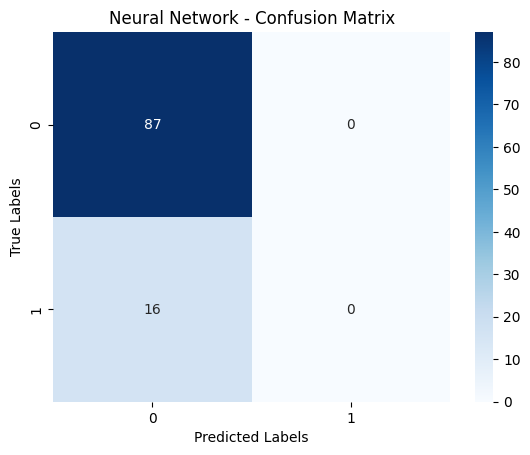

In [ ]:
cm_mlp = confusion_matrix(y_test, prediction_mlp)
sns.heatmap(cm_mlp, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Neural Network - Confusion Matrix")
plt.show()

Ada Boost

In [ ]:
!pip install scikit-learn
from sklearn.ensemble import AdaBoostClassifier # Import AdaBoostClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


adaboost_classifier = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_classifier.fit(x_train, y_train)
prediction_ab = adaboost_classifier.predict(x_test)
accuracy_ab = accuracy_score(y_test, prediction_ab)
precision_ab = precision_score(y_test, prediction_ab)
recall_ab = recall_score(y_test, prediction_ab)
f1_ab = f1_score(y_test, prediction_ab)
print("AdaBoost - Accuracy:", accuracy_ab)
print("Precision:", precision_ab)
print("Recall:", recall_ab)
print("F1 Score:", f1_ab)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AdaBoost - Accuracy: 0.8543689320388349
Precision: 0.8913043478260869
Recall: 0.9425287356321839
F1 Score: 0.9162011173184358


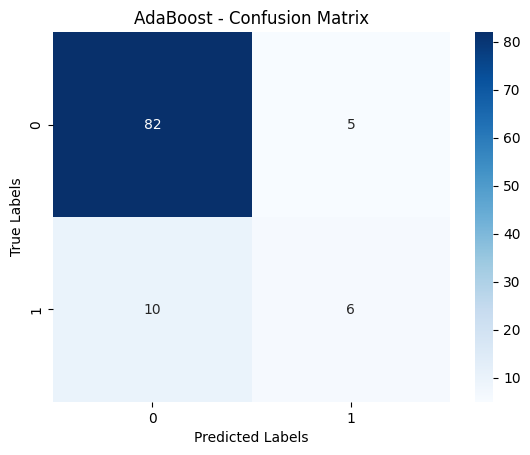

In [ ]:
cm_ab = confusion_matrix(y_test, prediction_ab)
sns.heatmap(cm_ab, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("AdaBoost - Confusion Matrix")
plt.show()

Logistic Regression

In [ ]:
#Fitting simple linear regression to the training test
Model1 = LogisticRegression()
Model1.fit(x_train, y_train)
#Predicting the test set results
prediction1 = Model1.predict(x_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
prediction1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1,
       1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
confusion_matrix(y_test,prediction1)

array([[85,  2],
       [10,  6]])

In [ ]:
 accuracy_score(y_test,prediction1)

0.883495145631068

In [ ]:
from sklearn.metrics import precision_score
probs = Model1.predict_proba(x_test)
precision_score(y_test, prediction1, average = None)

array([0.89473684, 0.75      ])

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# assuming your predicted and actual labels are stored in variables y_pred and y_true, respectively
accuracy = accuracy_score(y_test, prediction1)
precision = precision_score(y_test, prediction1)
recall = recall_score(y_test, prediction1)
f1 = f1_score(y_test, prediction1)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.883495145631068
Precision: 0.8947368421052632
Recall: 0.9770114942528736
F1 score: 0.9340659340659341


In [ ]:
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
recall_score(y_test, prediction1, average = None)

array([0.97701149, 0.375     ])

In [ ]:
 f1_score(y_test, prediction1, average = None)

array([0.93406593, 0.5       ])

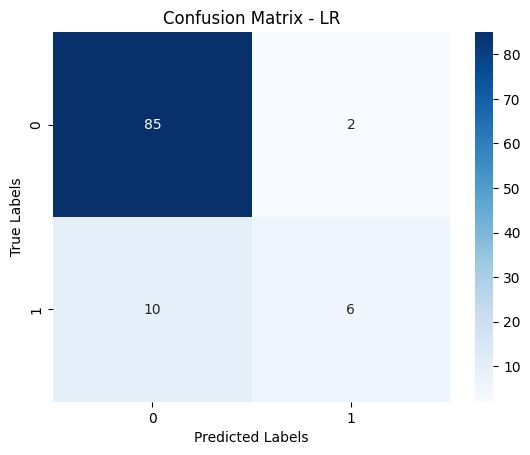

In [ ]:
cm = confusion_matrix(y_true = y_test, y_pred = prediction1)
#plot_confusion_matrix(cm,level,title = "confusion_matrix")
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - LR")
plt.show()

MLR (threshold of 0.8)

 MLR Accuracy: 0.9029
Precision: 0.9053
Recall: 0.9885
F1 Score: 0.9451


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel

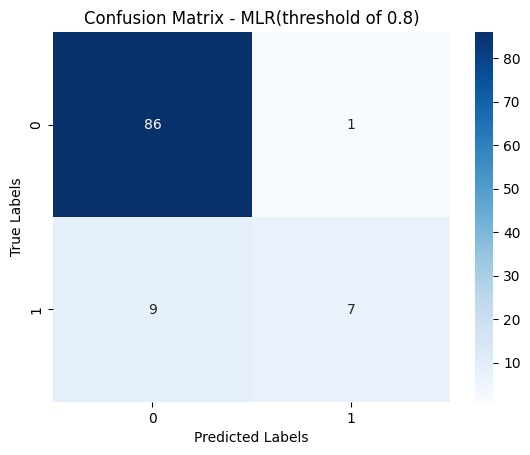

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import SelectFromModel
import seaborn as sns
import matplotlib.pyplot as plt

# Feature selection using Logistic Regression with an 80% threshold
selector = SelectFromModel(LogisticRegression(), threshold=0.8)
x_train_selected = selector.fit_transform(x_train, y_train)
x_test_selected = selector.transform(x_test)

# Modified Logistic Regression (MLR)
MLR = LogisticRegression()
MLR.fit(x_train_selected, y_train)

# Predictions
predictions = MLR.predict(x_test_selected)
probs = MLR.predict_proba(x_test_selected)

# Performance Metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)

# Display results
print(f" MLR Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - MLR(threshold of 0.8)")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


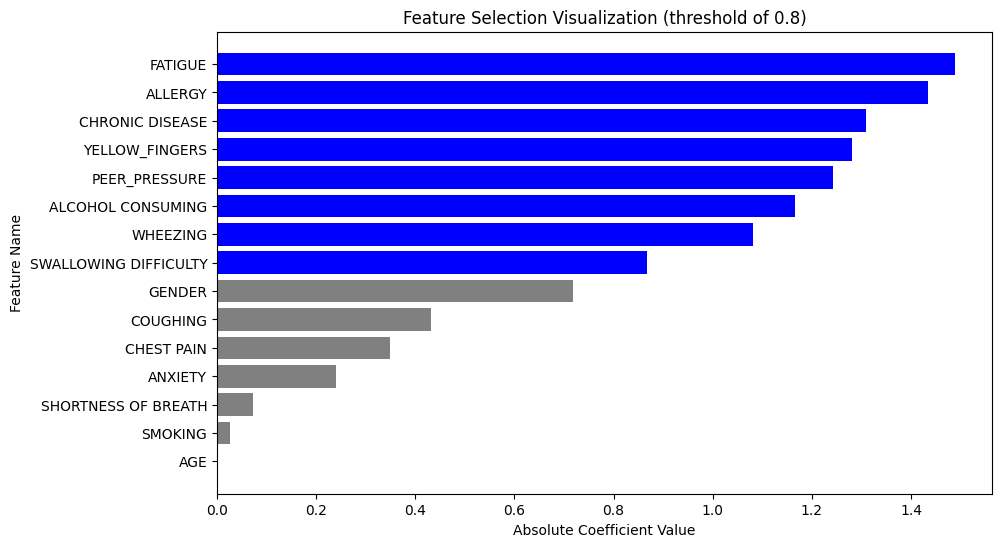

In [ ]:
import numpy as np

# Get feature importance (absolute values of coefficients)
base_model = LogisticRegression()
base_model.fit(x_train, y_train)
feature_importance = np.abs(base_model.coef_).flatten()

# Get feature names
feature_names = x.columns  # Assuming X is your original DataFrame before selection
selected_features_mask = selector.get_support()

# Separate selected and removed features
selected_features = feature_names[selected_features_mask]
removed_features = feature_names[~selected_features_mask]

# Create a sorted list of feature importance values with names
sorted_indices = np.argsort(feature_importance)  # Sort indices by importance
sorted_features = np.array(feature_names)[sorted_indices]  # Sorted feature names
sorted_importance = feature_importance[sorted_indices]  # Sorted importance

# Plot the feature selection results
plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features, sorted_importance, color=["blue" if feature in selected_features else "gray" for feature in sorted_features])

plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Feature Selection Visualization (threshold of 0.8)")
plt.show()


MLR (threshold of 0.4
)

Accuracy: 0.967741935483871
Precision: 0.9833333333333333
Recall: 0.9833333333333333
F1 Score: 0.9833333333333333


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


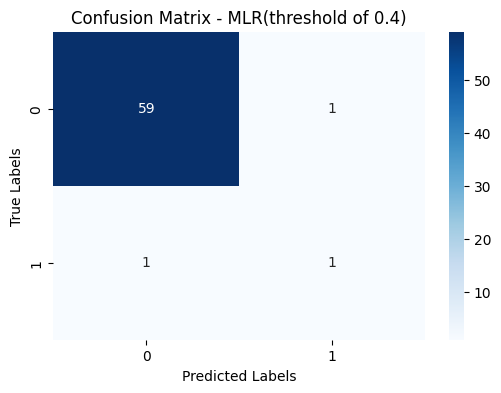

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectFromModel

# Assuming lung_data is your DataFrame and 'LUNG_CANCER' is the target
data = lung_data.copy() # Create a copy of lung_data and assign it to data
data.rename(columns={'LUNG_CANCER': 'target'}, inplace=True)  # Rename 'LUNG_CANCER' to 'target'
#Now data refers to lung_data and has a column called 'target'

y = data['target']  # Target variable is now accessible
X = data.drop(columns=['target'])  # Feature variables

# Splitting the dataset
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature selection using Logistic Regression with L1 penalty
base_model = LogisticRegression(penalty='l1', solver='liblinear')
base_model.fit(x_train, y_train)
selector = SelectFromModel(base_model, threshold=0.4, prefit=True)
x_train_selected = selector.transform(x_train)
x_test_selected = selector.transform(x_test)

# Modified Logistic Regression (MLR)
MLR = LogisticRegression()
MLR.fit(x_train_selected, y_train)

# Predictions
prediction = MLR.predict(x_test_selected)

# Evaluation Metrics
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

# Confusion Matrix
cm = confusion_matrix(y_test, prediction)

# Results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - MLR(threshold of 0.4)")
plt.show()


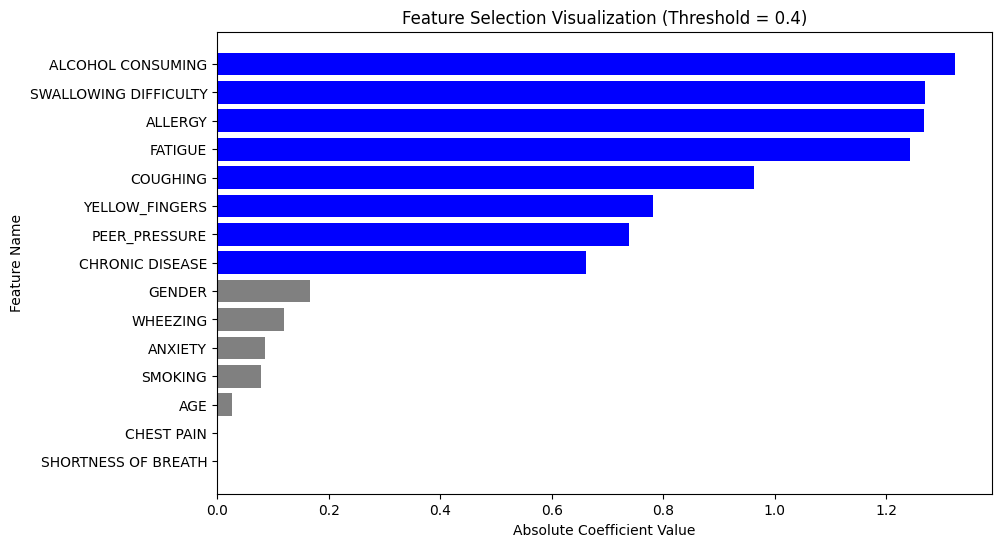

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get original feature names
feature_names = np.array(X.columns)

# Get model coefficients (absolute values)
coefficients = np.abs(base_model.coef_[0])

# Get selected features mask based on 0.4 threshold
selected_mask = coefficients > 0.4

# Sort features by coefficient values
sorted_indices = np.argsort(coefficients)[::-1]
sorted_features = feature_names[sorted_indices]
sorted_coefficients = coefficients[sorted_indices]
sorted_selected_mask = selected_mask[sorted_indices]

# Set colors: blue for selected features, gray for others
colors = ["blue" if selected else "gray" for selected in sorted_selected_mask]

# Plot the feature selection results
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_coefficients, color=colors)
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature Name")
plt.title("Feature Selection Visualization (Threshold = 0.4)")
plt.gca().invert_yaxis()  # Invert Y-axis for better readability
plt.show()


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier


GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


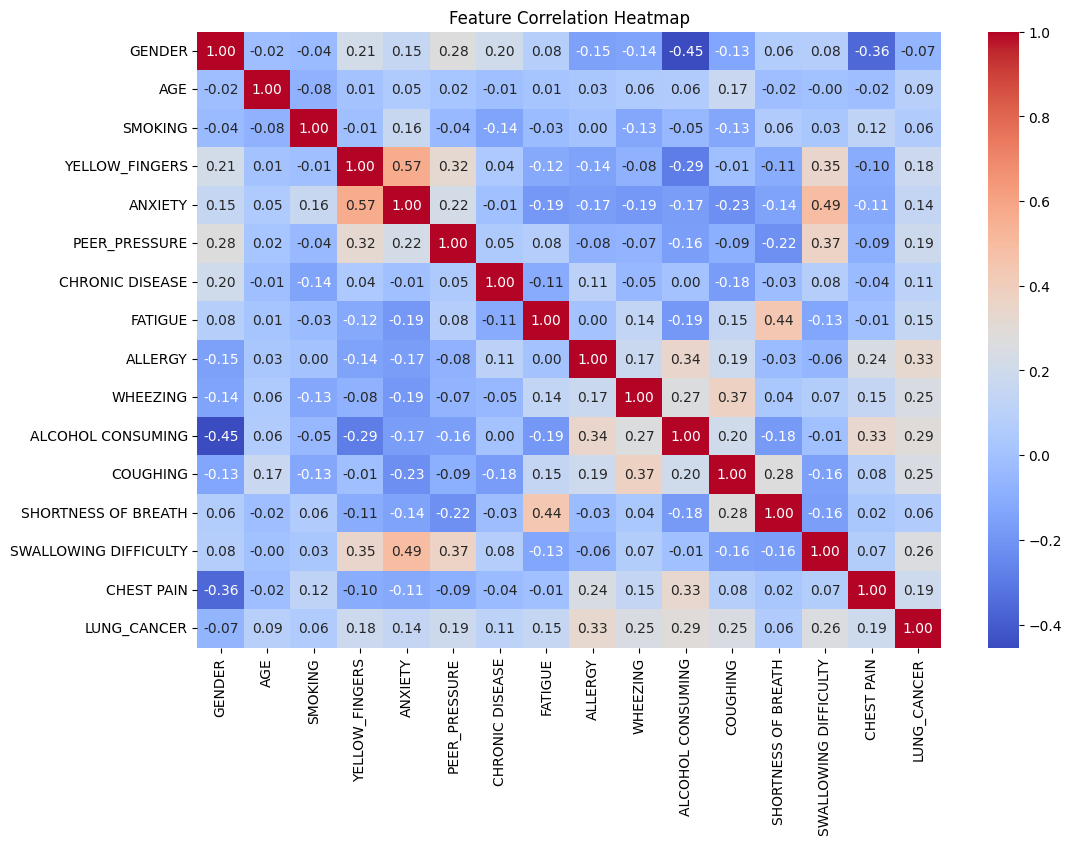

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Load dataset
dataset_url = "https://raw.githubusercontent.com/rohitinu6/Lung_Cancer_Prediction_Using_Machine_Learning/main/Dataset/survey%20lung%20cancer.csv"
df = pd.read_csv(dataset_url)

# Encode categorical variables
df['GENDER'] = df['GENDER'].map({"M": 1, "F": 2})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({"YES": 1, "NO": 0})

# Check for missing values
print(df.isnull().sum())

# Split dataset
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Ensure y_train is 1D
y_train = y_train.values.ravel()



# Evaluation Function
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n{model_name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()



# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


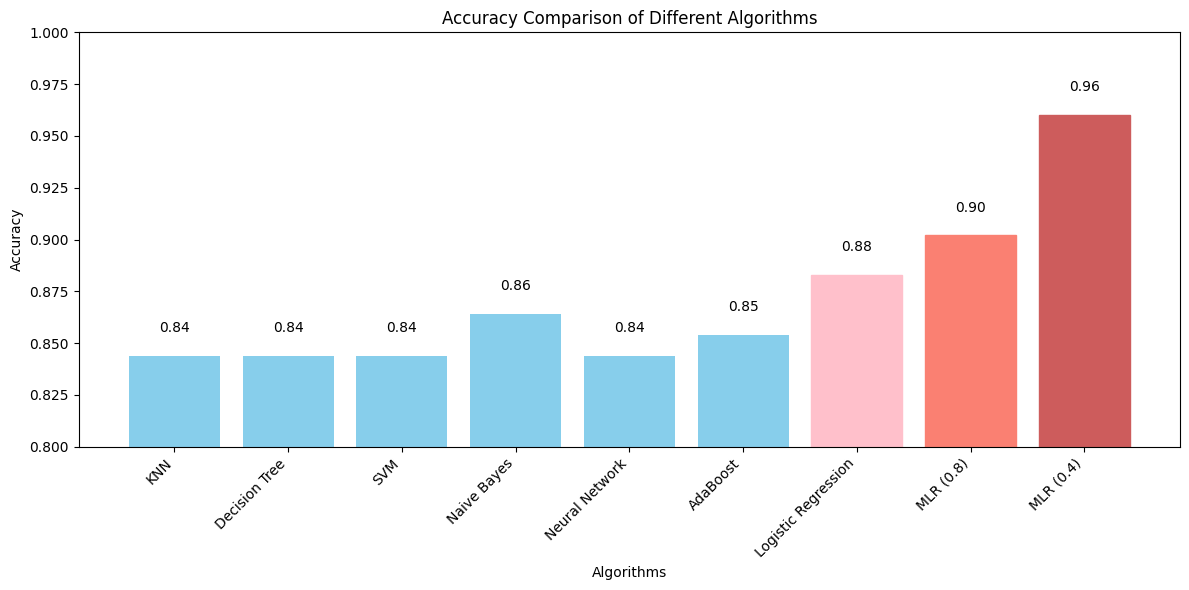

In [ ]:


import matplotlib.pyplot as plt
import numpy as np

# Algorithm names and their corresponding accuracies
algorithms = ['KNN', 'Decision Tree', 'SVM', 'Naive Bayes', 'Neural Network', 'AdaBoost', 'Logistic Regression', 'MLR (0.8)', 'MLR (0.4)']
accuracies = [0.844, 0.844, 0.844, 0.864, 0.844, 0.854, 0.883, 0.902, 0.96]


# Create bar graph
plt.figure(figsize=(12, 6))
bars = plt.bar(algorithms, accuracies, color='skyblue')

# Change colors for LR and MLRs
bars[algorithms.index('Logistic Regression')].set_color('pink')
bars[algorithms.index('MLR (0.8)')].set_color('salmon')
bars[algorithms.index('MLR (0.4)')].set_color('indianred')



plt.xlabel('Algorithms')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Different Algorithms')
plt.xticks(rotation=45, ha='right')
plt.ylim([0.80, 1.0])

# Add accuracy values on top of all bars
for i, alg in enumerate(algorithms):
    plt.text(i, accuracies[i] + 0.01, f'{accuracies[i]:.2f}', ha='center', va='bottom')


plt.tight_layout()
plt.show()